# laya-cuda-bench — report

Every table and chart below is computed from `results/` only. Cost assumptions are the constants in the next cell; change them and re-run.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
import pandas as pd, matplotlib.pyplot as plt
from harness import report as R

# ---- assumptions (stated in the post) ----
R.USD_PER_KWH = 0.12          # $/kWh
R.LIFETIME_YEARS = 3
R.CARD_USD.update({})         # override street prices here if needed
UTILISATION = [1.0, 0.4]      # 24/7 at the sustained rate, and a 40%-utilised fleet
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

## 1. Parity gate (per box)

In [2]:
rows = []
for p in R.RESULTS.glob('*/parity.json'):
    d = json.loads(p.read_text())
    for r in d['results']:
        rows.append({'box': p.parent.name, 'gpu': d['gpu'], 'model': r['model'], 'backend': r['backend'],
                     'argmax': f"{r['argmax_agreements']}/{r['questions']}", 'max_prob_err': r['probability_max_abs_error'],
                     'alloc_growth_B': r['stability']['allocated_growth_bytes'], 'verdict': r['verdict']})
parity = pd.DataFrame(rows)
parity.sort_values(['box', 'model', 'backend'])

,box,gpu,model,backend,argmax,max_prob_err,alloc_growth_B,verdict
2,h100nvl,NVIDIA H100 NVL,laya,ort-cuda-fp16,63/63,0.006300,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
3,h100nvl,NVIDIA H100 NVL,laya,ort-trt-fp16-maxb256,63/63,0.014914,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
8,h100nvl,NVIDIA H100 NVL,laya,torch-compile-max-autotune-fp16,63/63,0.005608,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
0,h100nvl,NVIDIA H100 NVL,laya,torch-eager-fp16,63/63,0.006725,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
1,h100nvl,NVIDIA H100 NVL,laya,torch-eager-fp32,63/63,0.000000,-4608,PASS
...,...,...,...,...,...,...,...,...
30,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya-typed-decisions,ort-trt-fp16-maxb64,63/63,0.004790,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
29,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya-typed-decisions,torch-compile-max-autotune-fp16,63/63,0.001462,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
26,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya-typed-decisions,torch-eager-bf16,63/63,0.007863,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"
25,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya-typed-decisions,torch-eager-fp16,63/63,0.002329,-4608,"PASS (fp16 error > 1e-3, port gated at 0.02)"


## 2. Backend shootout — latency vs batch (median of per-repeat medians, min/max spread)

batch                                                                        1       16       64       256
box              model             backend                         length                                 
h100nvl          laya              ort-cuda-fp16                   long     9.07   74.99   297.88  1212.13
                                                                   short    5.51   19.43    69.90   278.46
                                   ort-trt-fp16-maxb256            long     7.44   47.66   185.25   750.87
                                                                   short    3.81   16.02    57.93   226.93
                                   torch-compile-max-autotune-fp16 long     5.15   36.23   139.02   549.76
...                                                                          ...     ...      ...      ...
zbook-rtxpro5000 laya-multilingual torch-compile-max-autotune-fp16 short    3.03   13.00    48.26   242.73
                                   torch-eager-fp16                long     6.93   88.74   432.95  1786.86
                                                                   short    6.54   18.46    78.65   406.07
                                   torch-eager-fp32                long    16.68  254.06  1100.35  4019.48
                                                                   short    6.76   56.22   188.05  1000.68

[80 rows x 4 columns]

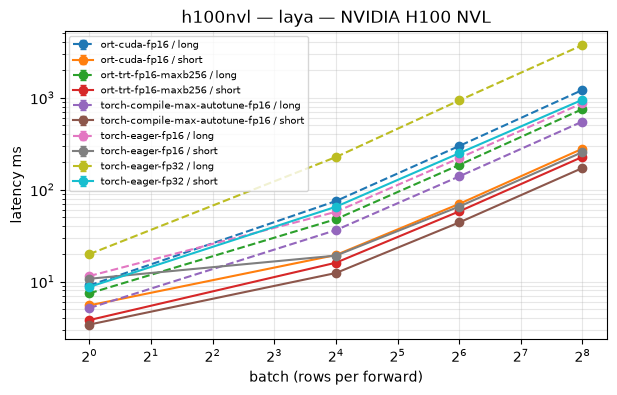

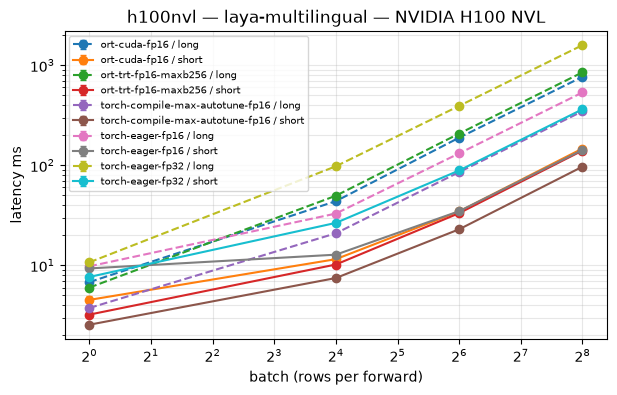

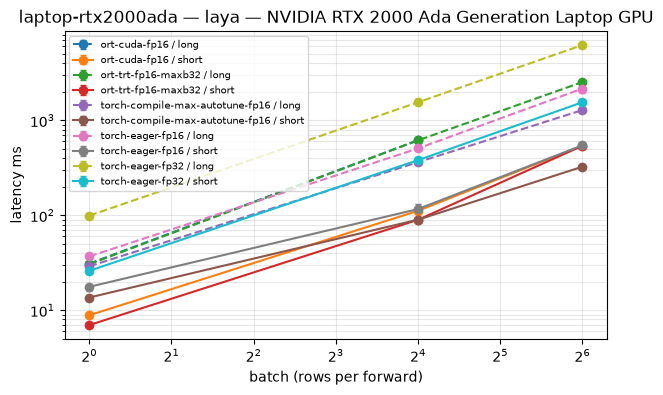

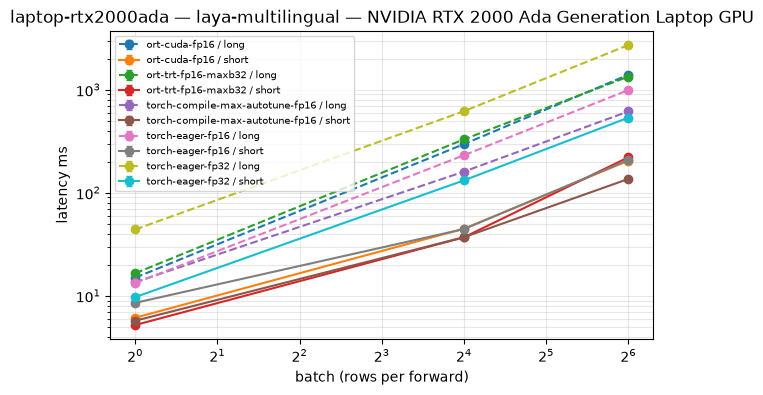

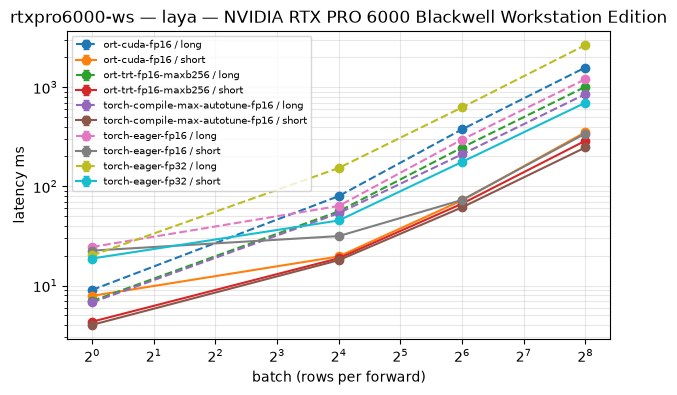

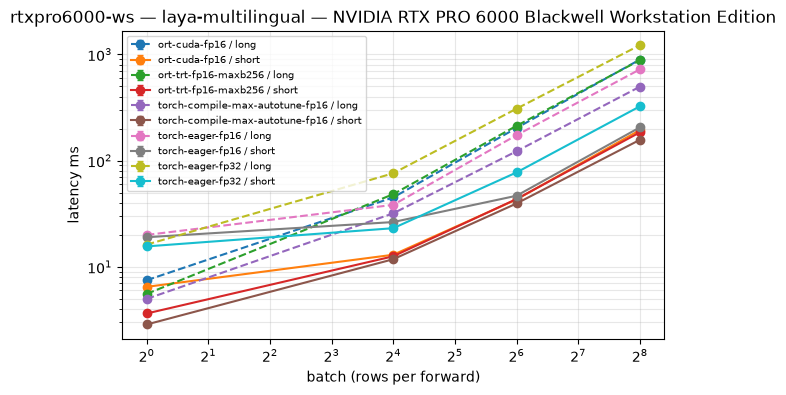

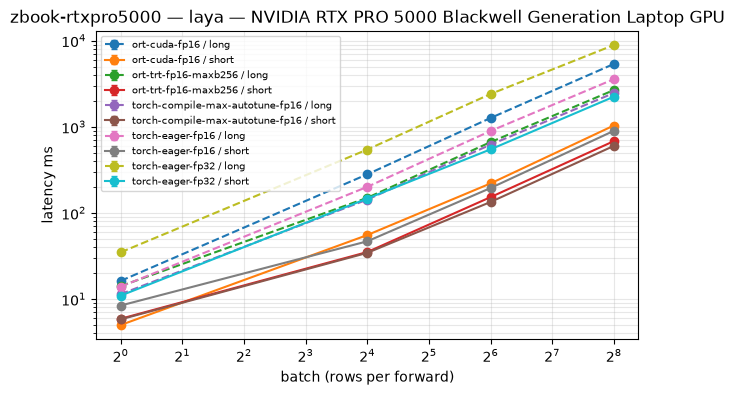

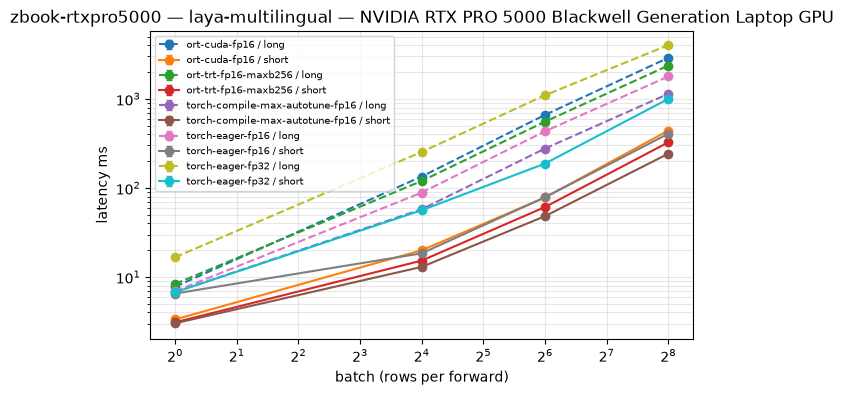

In [3]:
cells = R.shootout()
if not cells.empty:
    for (box, model), g in cells.groupby(['box', 'model']):
        fig, ax = plt.subplots(figsize=(7, 4))
        for (backend, length), gg in g.groupby(['backend', 'length']):
            gg = gg.sort_values('batch')
            ax.errorbar(gg['batch'], gg['median_ms'], yerr=[gg['median_ms'] - gg['min_ms'], gg['max_ms'] - gg['median_ms']],
                        marker='o', capsize=2, label=f'{backend} / {length}', ls='-' if length == 'short' else '--')
        ax.set_xscale('log', base=2); ax.set_yscale('log'); ax.set_xlabel('batch (rows per forward)'); ax.set_ylabel('latency ms')
        ax.set_title(f'{box} — {model} — {g["gpu"].iloc[0]}'); ax.grid(True, which='both', alpha=.3); ax.legend(fontsize=7)
    display(cells.pivot_table(index=['box', 'model', 'backend', 'length'], columns='batch', values='median_ms').round(2))
else:
    print('no shootout results yet')

## 3. Server scenario — latency vs offered load, and sustained decisions/s under each SLO

decisions_per_day_M       decisions_per_s        watts_mean       
slo_ms                                                                         50    130             50     130        50     130
box               model             label backend                                                                                
h100nvl           laya                    ort-trt-fp16-maxb256                 9.0  15.1           104.7  174.7      192.6  235.8
                                          torch-eager-fp16                     3.4   8.1            39.2   93.3      152.4  181.0
                  laya-multilingual       ort-trt-fp16-maxb256                 NaN   8.0             NaN   92.7        NaN  185.1
                                          torch-eager-fp16                     NaN   5.7             NaN   65.5        NaN  148.9
laptop-rtx2000ada laya-multilingual       torch-eager-fp16                     NaN   0.4             NaN    4.6        NaN   15.8
rtxpro6000-ws     laya                    ort-trt-fp16-maxb256                 NaN  12.6             NaN  145.7        NaN  186.5
                                          torch-eager-fp16                     NaN  12.6             NaN  145.6        NaN  212.1
                  laya-multilingual       torch-eager-fp16                     NaN  12.6             NaN  145.6        NaN  170.3
zbook-rtxpro5000  laya                    ort-trt-fp16-maxb256                 1.3   3.6            15.0   41.8       30.6   50.0
                                          torch-eager-fp16                     NaN   3.6             NaN   41.8        NaN   56.4
                  laya-multilingual       ort-trt-fp16-maxb256                 NaN   2.5             NaN   29.3        NaN   39.8
                                          torch-eager-fp16                     1.3   4.9            15.0   56.4       30.1   54.1

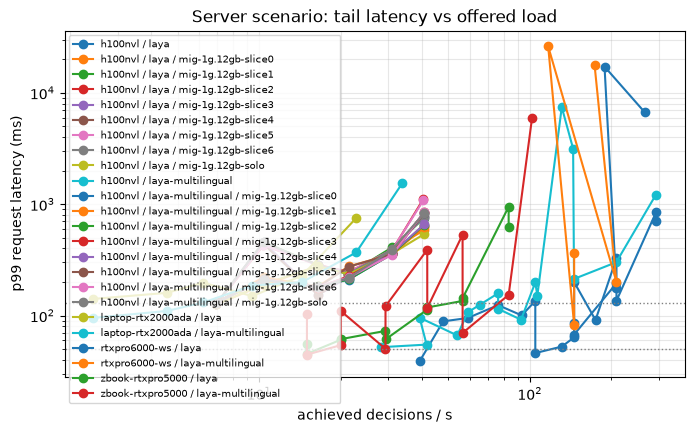

In [4]:
steps, sus = R.sweep_steps(), R.sweeps()
if not steps.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for key, g in steps.groupby(['box', 'model', 'label']):
        g = g.sort_values('target_qps')
        ax.plot(g['decisions_per_s'], g['p99_ms'], marker='o', label=' / '.join(k for k in key if k))
    for slo in (50, 130):
        ax.axhline(slo, color='grey', ls=':', lw=1); ax.text(ax.get_xlim()[0], slo, f' p99 = {slo} ms', va='bottom', fontsize=8)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('achieved decisions / s'); ax.set_ylabel('p99 request latency (ms)')
    ax.set_title('Server scenario: tail latency vs offered load'); ax.grid(True, which='both', alpha=.3); ax.legend(fontsize=7)
    sus['decisions_per_day_M'] = sus['decisions_per_s'] * 86400 / 1e6
    display(sus.pivot_table(index=['box', 'model', 'label', 'backend'], columns='slo_ms', values=['decisions_per_s', 'decisions_per_day_M', 'watts_mean']).round(1))
else:
    print('no sweeps yet')

## 4. Offline ceiling and baselines

In [5]:
off = R.offline(); base = R.baselines(); jev = R.jev()
if not off.empty: display(off[['box', 'gpu', 'model', 'backend', 'length', 'batch', 'decisions_per_s', 'watts_mean', 'joules_per_decision', 'peak_vram_mb']].round(3))
if not base.empty: display(base[['box', 'label', 'concurrency', 'ok', 'p50_ms', 'p99_ms', 'decisions_per_s', 'mean_prompt_tokens', 'mean_completion_tokens']].round(1))
if not jev.empty: display(jev[['concurrency', 'ok', 'p50_ms', 'p95_ms', 'p99_ms', 'achieved_qps', 'mean_input_tokens_per_request', 'rate_limited']].round(1))

,box,gpu,model,backend,length,batch,decisions_per_s,watts_mean,joules_per_decision,peak_vram_mb
0,h100nvl,NVIDIA H100 NVL,laya-multilingual,torch-eager-fp16,medium,2048,646.549,330.287,0.511,23461.049
1,h100nvl,NVIDIA H100 NVL,laya,torch-eager-fp16,medium,2048,339.141,352.577,1.040,34441.576
2,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya-multilingual,torch-eager-fp16,medium,1024,184.730,92.331,0.500,12377.341
3,zbook-rtxpro5000,NVIDIA RTX PRO 5000 Blackwell Generation Lapto...,laya,torch-eager-fp16,medium,1024,85.359,92.760,1.087,18041.321
4,laptop-rtx2000ada,NVIDIA RTX 2000 Ada Generation Laptop GPU,laya-multilingual,torch-eager-fp16,medium,256,84.492,44.187,0.523,4033.561
5,laptop-rtx2000ada,NVIDIA RTX 2000 Ada Generation Laptop GPU,laya,torch-eager-fp16,medium,128,39.463,44.684,1.132,3667.980
6,rtxpro6000-ws,NVIDIA RTX PRO 6000 Blackwell Workstation Edition,laya-multilingual,torch-eager-fp16,medium,2048,496.695,346.963,0.699,23461.049
7,rtxpro6000-ws,NVIDIA RTX PRO 6000 Blackwell Workstation Edition,laya,torch-eager-fp16,medium,2048,272.547,411.815,1.511,34441.576


,box,label,concurrency,ok,p50_ms,p99_ms,decisions_per_s,mean_prompt_tokens,mean_completion_tokens
0,h100nvl,qwen3.5-35b-a3b-fp8-direct,1,60,149.4,157.4,20.0,204.9,27.0
1,h100nvl,qwen3.5-35b-a3b-fp8-direct,16,120,598.7,700.6,74.4,207.5,26.9
2,h100nvl,qwen3.5-35b-a3b-fp8-direct,64,240,874.7,1055.7,200.2,279.5,27.0
3,h100nvl,qwen3.5-4b,1,60,129.8,1887.1,18.8,204.9,27.0
4,h100nvl,qwen3.5-4b,16,120,509.3,1382.1,69.4,207.5,27.0
5,h100nvl,qwen3.5-4b,64,240,902.4,987.1,199.7,279.5,27.0
6,h100nvl,qwen3.5-35b-a3b-fp8,1,60,155.9,203.3,17.7,204.9,27.0
7,h100nvl,qwen3.5-35b-a3b-fp8,16,120,3199.6,3203.7,15.0,207.5,27.0
8,h100nvl,qwen3.5-35b-a3b-fp8,64,240,12799.7,12810.0,15.0,279.5,27.0
9,rtxpro6000-ws,qwen3.5-4b,1,60,218.5,11379.3,7.3,204.9,27.0


,concurrency,ok,p50_ms,p95_ms,p99_ms,achieved_qps,mean_input_tokens_per_request,rate_limited
0,1,100,151.5,222.7,334.2,6.1,483.7,False
1,8,200,157.1,224.5,301.6,10.0,532.4,False
2,32,300,164.1,239.4,329.0,10.0,583.1,False


## 5. Cost per million decisions (at the p99 ≤ 130 ms operating point)

,column,utilisation,energy_usd_per_m,amortised_usd_per_m,total_usd_per_m
0,h100nvl whole laya-multilingual,1.0,0.067,3.420,3.486
1,h100nvl whole laya-multilingual,0.4,0.067,8.550,8.616
2,h100nvl whole laya,1.0,0.065,3.400,3.464
3,h100nvl whole laya,0.4,0.065,8.499,8.564
4,h100nvl whole laya,1.0,0.045,1.815,1.860
5,h100nvl whole laya,0.4,0.045,4.538,4.583
6,h100nvl whole laya-multilingual,1.0,0.076,4.840,4.916
7,h100nvl whole laya-multilingual,0.4,0.076,12.100,12.175
8,zbook-rtxpro5000 whole laya-multilingual,1.0,0.045,0.902,0.947
9,zbook-rtxpro5000 whole laya-multilingual,0.4,0.045,2.255,2.301


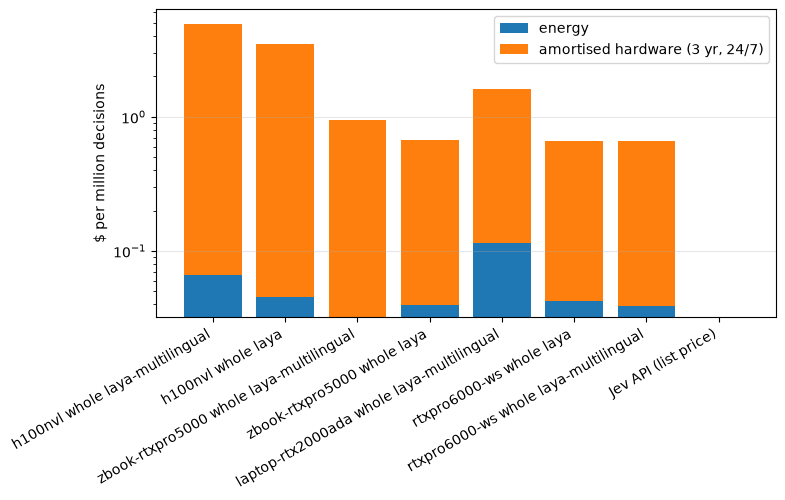

In [6]:
rows = []
if not sus.empty:
    gpu_of = {p.parent.name: json.loads(p.read_text())['gpu'] for p in R.RESULTS.glob('*/parity.json')}
    for _, s in sus[(sus.slo_ms == 130) & sus.decisions_per_s.notna()].iterrows():
        for u in UTILISATION:
            c = R.cost_per_million(s['decisions_per_s'], s['watts_mean'] or 0, gpu_of.get(s['box'], ''), utilisation=u)
            rows.append({'column': f"{s['box']} {s['label'] or 'whole'} {s['model']}", 'utilisation': u, **c})
if not jev.empty:
    tok = jev['mean_input_tokens_per_request'].mean()
    rows.append({'column': 'Jev API (list price)', 'utilisation': None, 'energy_usd_per_m': 0, 'amortised_usd_per_m': 0,
                 'total_usd_per_m': R.jev_cost_per_million(tok)})
cost = pd.DataFrame(rows)
if not cost.empty:
    display(cost.round(3))
    fig, ax = plt.subplots(figsize=(8, 4))
    c1 = cost[(cost.utilisation == 1.0) | cost.utilisation.isna()]
    ax.bar(c1['column'], c1['energy_usd_per_m'], label='energy'); ax.bar(c1['column'], c1['amortised_usd_per_m'], bottom=c1['energy_usd_per_m'], label='amortised hardware (3 yr, 24/7)')
    ax.set_ylabel('$ per million decisions'); ax.set_yscale('log'); ax.legend(); plt.xticks(rotation=30, ha='right'); ax.grid(True, axis='y', alpha=.3)